# Data Loader

The purpose of the data loader is to:

Load the raw OPM-MEG recordings from the original MATLAB (.mat) files.
Extract the information required for preprocessing.
Convert the data into a compact NumPy (.npz) format.
Verify that no information is lost during conversion.
Inspect the dataset structure before beginning preprocessing.

The output of this notebook is the loaded dataset, which serves as the input to the preprocessing pipeline.

- bexp.shape = (30, 856000)
- 15 physical OPM sensors × 2 measurement axes (strengh + direction) = 30 channels
- 856000: number of samples
- 2000 Hz sampling
- ~428 seconds (~7 min)

run0?.meg.mat
- "bexp": MEG signals, 30 × 856000 chanel x time
    
- "bexp_ext": trigger channel, 1 × 856000 when the stimulus happened
    
- "pick": sensor positions, 30 × 3
    
- Qpick: sensor orientations
- 
- "MEGinfo": metadata 


We want
X.shape = (n_trials, 30, n_times) trial × channel × time

250 auditory events
for each trigger we extract:
200 ms before
600 ms after

In [12]:
from pathlib import Path
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

The first step is to inspect one of the original MATLAB files.

In [13]:
def load_opm_run(filepath):

    data = loadmat(filepath)

    signals = data["bexp"]

    aux = data["bexp_ext"]

    info = data["MEGinfo"]

    fs = int(info["SampleFreq"][0,0][0,0])

    channel_names = [
        ch[0][0]
        for ch in info["MEGch_name"][0,0]
    ]

    positions = data["pick"]

    return {
        "signals": signals,
        "aux": aux,
        "fs": fs,
        "channel_names": channel_names,
        "positions": data["pick"],
        "orientations": data["Qpick"]
    }

In [14]:
def validate_data(mat_path, npz_path):
    
    mat_data = loadmat(mat_path)

    npz_data = np.load(
        npz_path,
        allow_pickle=True
    )
    
    assert mat_data["bexp"].shape == npz_data["signals"].shape
    assert mat_data["bexp_ext"].shape == npz_data["aux"].shape
    assert mat_data["pick"].shape == npz_data["positions"].shape
    assert mat_data["Qpick"].shape == npz_data["orientations"].shape

    checks = {

        "signals":
            np.allclose(
                mat_data["bexp"],
                npz_data["signals"]
            ),

        "aux":
            np.allclose(
                mat_data["bexp_ext"],
                npz_data["aux"]
            ),

        "positions":
            np.allclose(
                mat_data["pick"],
                npz_data["positions"]
            ),

        "orientations":
            np.allclose(
                mat_data["Qpick"],
                npz_data["orientations"]
            )
    }

    return checks

### Subject 002

In [15]:
RAW_ROOT = Path("../data/raw/002/OPM")
SAVE_ROOT = Path("../data/loaded/002")

SAVE_ROOT.mkdir(parents=True, exist_ok=True)

meg_files = sorted(RAW_ROOT.rglob("*.meg.mat"))

print(f"Found {len(meg_files)} OPM-MEG runs\n")

Found 8 OPM-MEG runs



In [16]:
for meg_file in meg_files:

    task = meg_file.parent.name.lower()

    run_name = meg_file.stem.replace(".meg", "")

    run = load_opm_run(meg_file)

    task_dir = SAVE_ROOT / task
    task_dir.mkdir(exist_ok=True)

    save_path = task_dir / f"{run_name}.npz"

    np.savez_compressed(
        save_path,
        signals=run["signals"],
        aux=run["aux"],
        fs=run["fs"],
        channel_names=np.array(
            run["channel_names"],
            dtype=object
        ),
        positions=run["positions"],
        orientations=run["orientations"]
    )

    print(
        f"{task:15s} "
        f"{run_name:8s} "
        f"signals={run['signals'].shape} "
        f"aux={run['aux'].shape}"
    )

    print(
        validate_data(
            meg_file,
            save_path
        )
    )

print("\nFinished.")

auditory        run01    signals=(30, 856000) aux=(1, 856000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
auditory        run02    signals=(30, 864000) aux=(1, 864000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run01    signals=(30, 682000) aux=(3, 682000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run02    signals=(30, 632000) aux=(3, 632000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run03    signals=(30, 628000) aux=(3, 628000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
rest            run01    signals=(30, 648000) aux=(1, 648000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
somatosensory   run01    signals=(30, 624000) aux=(1, 624000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
somatosensory   run02    signals=(30, 622000) aux=(1, 622000)


### Subject 005

In [17]:
RAW_ROOT = Path("../data/raw/005/OPM")
SAVE_ROOT = Path("../data/loaded/005")

SAVE_ROOT.mkdir(parents=True, exist_ok=True)

meg_files = sorted(RAW_ROOT.rglob("*.meg.mat"))

print(f"Found {len(meg_files)} OPM-MEG runs\n")

Found 8 OPM-MEG runs



In [18]:
for meg_file in meg_files:

    task = meg_file.parent.name.lower()

    run_name = meg_file.stem.replace(".meg", "")

    run = load_opm_run(meg_file)

    task_dir = SAVE_ROOT / task
    task_dir.mkdir(exist_ok=True)

    save_path = task_dir / f"{run_name}.npz"

    np.savez_compressed(
        save_path,
        signals=run["signals"],
        aux=run["aux"],
        fs=run["fs"],
        channel_names=np.array(
            run["channel_names"],
            dtype=object
        ),
        positions=run["positions"],
        orientations=run["orientations"]
    )

    print(
        f"{task:15s} "
        f"{run_name:8s} "
        f"signals={run['signals'].shape} "
        f"aux={run['aux'].shape}"
    )

    print(
        validate_data(
            meg_file,
            save_path
        )
    )

print("\nFinished.")

auditory        run01    signals=(30, 856000) aux=(1, 856000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
auditory        run02    signals=(30, 868000) aux=(1, 868000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run01    signals=(30, 610000) aux=(3, 610000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run02    signals=(30, 614000) aux=(3, 614000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run03    signals=(30, 612000) aux=(3, 612000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
rest            run01    signals=(30, 614000) aux=(1, 614000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
somatosensory   run01    signals=(30, 624000) aux=(1, 624000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
somatosensory   run02    signals=(30, 620000) aux=(1, 620000)


### Subject 006

In [19]:
RAW_ROOT = Path("../data/raw/006/OPM")
SAVE_ROOT = Path("../data/loaded/006")

SAVE_ROOT.mkdir(parents=True, exist_ok=True)

meg_files = sorted(RAW_ROOT.rglob("*.meg.mat"))

print(f"Found {len(meg_files)} OPM-MEG runs\n")

Found 8 OPM-MEG runs



In [20]:
for meg_file in meg_files:

    task = meg_file.parent.name.lower()

    run_name = meg_file.stem.replace(".meg", "")

    run = load_opm_run(meg_file)

    task_dir = SAVE_ROOT / task
    task_dir.mkdir(exist_ok=True)

    save_path = task_dir / f"{run_name}.npz"

    np.savez_compressed(
        save_path,
        signals=run["signals"],
        aux=run["aux"],
        fs=run["fs"],
        channel_names=np.array(
            run["channel_names"],
            dtype=object
        ),
        positions=run["positions"],
        orientations=run["orientations"]
    )

    print(
        f"{task:15s} "
        f"{run_name:8s} "
        f"signals={run['signals'].shape} "
        f"aux={run['aux'].shape}"
    )

    print(
        validate_data(
            meg_file,
            save_path
        )
    )

print("\nFinished.")

auditory        run01    signals=(30, 842000) aux=(1, 842000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
auditory        run02    signals=(30, 856000) aux=(1, 856000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run01    signals=(30, 640000) aux=(3, 640000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run02    signals=(30, 700000) aux=(3, 700000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run03    signals=(30, 622000) aux=(3, 622000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
rest            run01    signals=(30, 614000) aux=(1, 614000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
somatosensory   run01    signals=(30, 674000) aux=(1, 674000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
somatosensory   run02    signals=(30, 622000) aux=(1, 622000)


### Subject 093

In [21]:
RAW_ROOT = Path("../data/raw/093/OPM")
SAVE_ROOT = Path("../data/loaded/093")

SAVE_ROOT.mkdir(parents=True, exist_ok=True)

meg_files = sorted(RAW_ROOT.rglob("*.meg.mat"))

print(f"Found {len(meg_files)} OPM-MEG runs\n")

Found 8 OPM-MEG runs



In [22]:
for meg_file in meg_files:

    task = meg_file.parent.name.lower()

    run_name = meg_file.stem.replace(".meg", "")

    run = load_opm_run(meg_file)

    task_dir = SAVE_ROOT / task
    task_dir.mkdir(exist_ok=True)

    save_path = task_dir / f"{run_name}.npz"

    np.savez_compressed(
        save_path,
        signals=run["signals"],
        aux=run["aux"],
        fs=run["fs"],
        channel_names=np.array(
            run["channel_names"],
            dtype=object
        ),
        positions=run["positions"],
        orientations=run["orientations"]
    )

    print(
        f"{task:15s} "
        f"{run_name:8s} "
        f"signals={run['signals'].shape} "
        f"aux={run['aux'].shape}"
    )

    print(
        validate_data(
            meg_file,
            save_path
        )
    )

print("\nFinished.")

auditory        run01    signals=(30, 854000) aux=(1, 854000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
auditory        run02    signals=(30, 848000) aux=(1, 848000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run01    signals=(30, 620000) aux=(3, 620000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run02    signals=(30, 614000) aux=(3, 614000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
motor           run03    signals=(30, 670000) aux=(3, 670000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
rest            run01    signals=(30, 612000) aux=(1, 612000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
somatosensory   run01    signals=(30, 660000) aux=(1, 660000)
{'signals': True, 'aux': True, 'positions': True, 'orientations': True}
somatosensory   run02    signals=(30, 636000) aux=(1, 636000)


The NumPy format is preferred because

it loads much faster in Python,
it stores only the required variables,
it avoids repeatedly parsing MATLAB structures,
it integrates directly with NumPy, SciPy and MNE-Python.

No numerical information is lost because the original arrays are copied directly into the .npz file.

### Auditory Task

In [34]:
mat = loadmat(
    "../data/raw/002/OPM/Auditory/run01.meg.mat"
)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'meg_parm', 'bexp', 'refmg', 'bexp_ext', 'CoordType', 'MEGinfo', 'Measurement', 'pick', 'Qpick', 'ref_pick', 'ref_Qpick', 'PositionFile'])


dict_keys
- '__header__',
- '__version__', 
- '__globals__', 
- 'meg_parm', 
- 'bexp', 
- 'refmg', 
- 'bexp_ext', 
- 'CoordType', 
- 'MEGinfo', 
- 'Measurement', 
- 'pick', 
- 'Qpick', 
- 'ref_pick', 
- 'ref_Qpick', 
- 'PositionFile'


In [35]:
for key, value in mat.items():

    if key.startswith("__"):
        continue

    print("\n", key)

    print("type:", type(value))

    if hasattr(value, "shape"):
        print("shape:", value.shape)

    if isinstance(value, np.ndarray):
        print("dtype:", value.dtype)


 meg_parm
type: <class 'numpy.ndarray'>
shape: (1, 1)
dtype: [('Measurement', 'O'), ('device', 'O'), ('num_run', 'O'), ('pos_file', 'O'), ('output_dir', 'O'), ('lvm_file', 'O'), ('comment_file', 'O'), ('meg_file', 'O')]

 bexp
type: <class 'numpy.ndarray'>
shape: (30, 856000)
dtype: float64

 refmg
type: <class 'numpy.ndarray'>
shape: (0, 856000)
dtype: uint8

 bexp_ext
type: <class 'numpy.ndarray'>
shape: (1, 856000)
dtype: float64

 CoordType
type: <class 'numpy.ndarray'>
shape: (1,)
dtype: <U11

 MEGinfo
type: <class 'numpy.ndarray'>
shape: (1, 1)
dtype: [('Measurement', 'O'), ('device', 'O'), ('Nsample', 'O'), ('Nrepeat', 'O'), ('SampleFreq', 'O'), ('Pretrigger', 'O'), ('Nchannel', 'O'), ('MEGch_id', 'O'), ('MEGch_name', 'O'), ('ActiveChannel', 'O'), ('ChannelInfo', 'O'), ('sensor_weight', 'O'), ('ExtraChannelInfo', 'O'), ('ActiveTrial', 'O'), ('Trial', 'O'), ('Vcenter', 'O'), ('Vradius', 'O'), ('MEG_ID', 'O'), ('MRI_ID', 'O')]

 Measurement
type: <class 'numpy.ndarray'>
shape: (1

In [36]:
data = np.load(
    "../data/loaded/002/auditory/run01.npz",
    allow_pickle=True
)

aux = data["aux"]

print(aux.shape)

(1, 856000)


-0.267441
4.769223


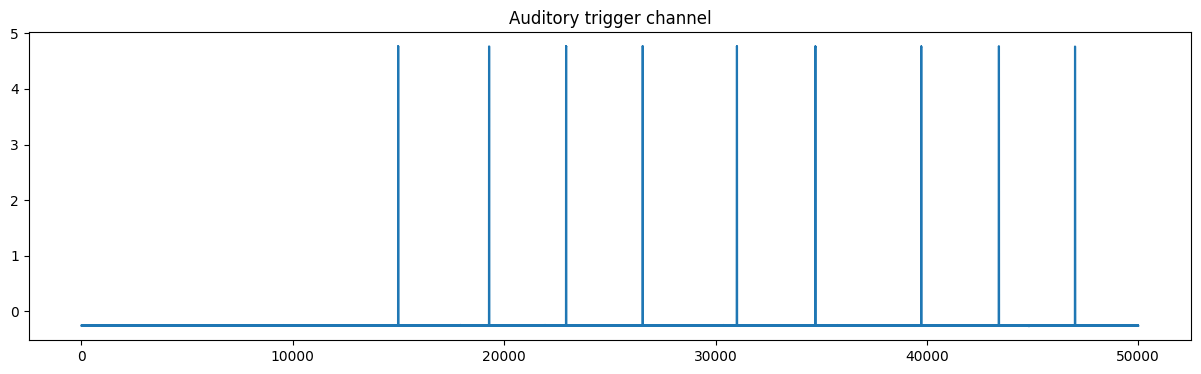

In [37]:
trigger = aux[0]

print(trigger.min())
print(trigger.max())

plt.figure(figsize=(15,4))
plt.plot(trigger[:50000])
plt.title("Auditory trigger channel")
plt.show()

events: 200


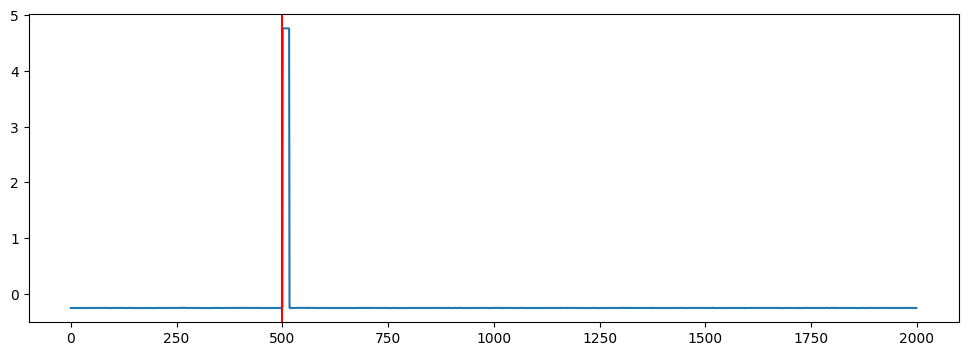

In [38]:
threshold = 2.0

binary = trigger > threshold

onsets = np.where(
    np.diff(binary.astype(int)) == 1
)[0]

print("events:", len(onsets))

first = onsets[0]

plt.figure(figsize=(12,4))
plt.plot(
    trigger[first-500:first+1500]
)
plt.axvline(500,color="r")
plt.show()

This graph will be used to divide the continuous recording into individual trials.

### Somatosensory Task

In [26]:
mat = loadmat(
    "../data/raw/002/OPM/Somatosensory/run01.meg.mat"
)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'meg_parm', 'bexp', 'refmg', 'bexp_ext', 'CoordType', 'MEGinfo', 'Measurement', 'pick', 'Qpick', 'ref_pick', 'ref_Qpick', 'PositionFile'])


dict_keys
- '__header__', 
- '__version__', 
- '__globals__', 
- 'meg_parm', 
- 'bexp', 
- 'refmg', 
- 'bexp_ext', 
- 'CoordType', 
- 'MEGinfo', 
- 'Measurement', 
- 'pick', 
- 'Qpick', 
- 'ref_pick', 
- 'ref_Qpick', 
- 'PositionFile'

In [27]:
for key, value in mat.items():

    if key.startswith("__"):
        continue

    print("\n", key)

    print("type:", type(value))

    if hasattr(value, "shape"):
        print("shape:", value.shape)

    if isinstance(value, np.ndarray):
        print("dtype:", value.dtype)


 meg_parm
type: <class 'numpy.ndarray'>
shape: (1, 1)
dtype: [('Measurement', 'O'), ('device', 'O'), ('num_run', 'O'), ('pos_file', 'O'), ('output_dir', 'O'), ('lvm_file', 'O'), ('comment_file', 'O'), ('meg_file', 'O')]

 bexp
type: <class 'numpy.ndarray'>
shape: (30, 624000)
dtype: float64

 refmg
type: <class 'numpy.ndarray'>
shape: (0, 624000)
dtype: uint8

 bexp_ext
type: <class 'numpy.ndarray'>
shape: (1, 624000)
dtype: float64

 CoordType
type: <class 'numpy.ndarray'>
shape: (1,)
dtype: <U11

 MEGinfo
type: <class 'numpy.ndarray'>
shape: (1, 1)
dtype: [('Measurement', 'O'), ('device', 'O'), ('Nsample', 'O'), ('Nrepeat', 'O'), ('SampleFreq', 'O'), ('Pretrigger', 'O'), ('Nchannel', 'O'), ('MEGch_id', 'O'), ('MEGch_name', 'O'), ('ActiveChannel', 'O'), ('ChannelInfo', 'O'), ('sensor_weight', 'O'), ('ExtraChannelInfo', 'O'), ('ActiveTrial', 'O'), ('Trial', 'O'), ('Vcenter', 'O'), ('Vradius', 'O'), ('MEG_ID', 'O'), ('MRI_ID', 'O')]

 Measurement
type: <class 'numpy.ndarray'>
shape: (1

### Motor Task

In [28]:
mat = loadmat(
    "../data/raw/002/OPM/Motor/run01.meg.mat"
)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'meg_parm', 'bexp', 'refmg', 'bexp_ext', 'CoordType', 'MEGinfo', 'Measurement', 'pick', 'Qpick', 'ref_pick', 'ref_Qpick', 'PositionFile'])


dict_keys
- '__header__', 
- '__version__', 
- '__globals__', 
- 'meg_parm', 
- 'bexp', 
- 'refmg', 
- 'bexp_ext', 
- 'CoordType', 
- 'MEGinfo', 
- 'Measurement', 
- 'pick', 
- 'Qpick', 
- 'ref_pick', 
- 'ref_Qpick', 
- 'PositionFile'

In [29]:
for key, value in mat.items():

    if key.startswith("__"):
        continue

    print("\n", key)

    print("type:", type(value))

    if hasattr(value, "shape"):
        print("shape:", value.shape)

    if isinstance(value, np.ndarray):
        print("dtype:", value.dtype)


 meg_parm
type: <class 'numpy.ndarray'>
shape: (1, 1)
dtype: [('Measurement', 'O'), ('device', 'O'), ('num_run', 'O'), ('pos_file', 'O'), ('output_dir', 'O'), ('lvm_file', 'O'), ('comment_file', 'O'), ('meg_file', 'O')]

 bexp
type: <class 'numpy.ndarray'>
shape: (30, 682000)
dtype: float64

 refmg
type: <class 'numpy.ndarray'>
shape: (0, 682000)
dtype: uint8

 bexp_ext
type: <class 'numpy.ndarray'>
shape: (3, 682000)
dtype: float64

 CoordType
type: <class 'numpy.ndarray'>
shape: (1,)
dtype: <U11

 MEGinfo
type: <class 'numpy.ndarray'>
shape: (1, 1)
dtype: [('Measurement', 'O'), ('device', 'O'), ('Nsample', 'O'), ('Nrepeat', 'O'), ('SampleFreq', 'O'), ('Pretrigger', 'O'), ('Nchannel', 'O'), ('MEGch_id', 'O'), ('MEGch_name', 'O'), ('ActiveChannel', 'O'), ('ChannelInfo', 'O'), ('sensor_weight', 'O'), ('ExtraChannelInfo', 'O'), ('ActiveTrial', 'O'), ('Trial', 'O'), ('Vcenter', 'O'), ('Vradius', 'O'), ('MEG_ID', 'O'), ('MRI_ID', 'O')]

 Measurement
type: <class 'numpy.ndarray'>
shape: (1

### Rest Task

In [31]:
mat = loadmat(
    "../data/raw/002/OPM/Rest/run01.meg.mat"
)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'meg_parm', 'bexp', 'refmg', 'bexp_ext', 'CoordType', 'MEGinfo', 'Measurement', 'pick', 'Qpick', 'ref_pick', 'ref_Qpick', 'PositionFile'])


dict_keys
- '__header__', 
- '__version__', 
- '__globals__', 
- 'meg_parm', 
- 'bexp', 
- 'refmg', 
- 'bexp_ext', 
- 'CoordType', 
- 'MEGinfo', 
- 'Measurement', 
- 'pick', 
- 'Qpick', 
- 'ref_pick', 
- 'ref_Qpick', 
- 'PositionFile'

In [ ]:
for key, value in mat.items():

    if key.startswith("__"):
        continue

    print("\n", key)

    print("type:", type(value))

    if hasattr(value, "shape"):
        print("shape:", value.shape)

    if isinstance(value, np.ndarray):
        print("dtype:", value.dtype)


 meg_parm
type: <class 'numpy.ndarray'>
shape: (1, 1)
dtype: [('Measurement', 'O'), ('device', 'O'), ('num_run', 'O'), ('pos_file', 'O'), ('output_dir', 'O'), ('lvm_file', 'O'), ('comment_file', 'O'), ('meg_file', 'O')]

 bexp
type: <class 'numpy.ndarray'>
shape: (30, 648000)
dtype: float64

 refmg
type: <class 'numpy.ndarray'>
shape: (0, 648000)
dtype: uint8

 bexp_ext
type: <class 'numpy.ndarray'>
shape: (1, 648000)
dtype: float64

 CoordType
type: <class 'numpy.ndarray'>
shape: (1,)
dtype: <U11

 MEGinfo
type: <class 'numpy.ndarray'>
shape: (1, 1)
dtype: [('Measurement', 'O'), ('device', 'O'), ('Nsample', 'O'), ('Nrepeat', 'O'), ('SampleFreq', 'O'), ('Pretrigger', 'O'), ('Nchannel', 'O'), ('MEGch_id', 'O'), ('MEGch_name', 'O'), ('ActiveChannel', 'O'), ('ChannelInfo', 'O'), ('sensor_weight', 'O'), ('ExtraChannelInfo', 'O'), ('ActiveTrial', 'O'), ('Trial', 'O'), ('Vcenter', 'O'), ('Vradius', 'O'), ('MEG_ID', 'O'), ('MRI_ID', 'O')]

 Measurement
type: <class 'numpy.ndarray'>
shape: (1